In [2]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\park2\appdata\local\temp\pip-req-build-1cugj26s
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36876 sha256=b0691db30efb1027d3eba199e88a34b1e27a1d742aeeb5076c4627697fdf7e04
  Stored in directory: C:\Users\park2\AppData\Local\Temp\pip-ephem-wheel-cache-do18knan\wheels\15\d7\bd\05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\park2\AppData\Local\Temp\pip-req-build-1cugj26s'

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading SAM model... this might take a few seconds.

Generating masks for: pcd0800r.png
-> Total masks found: 12


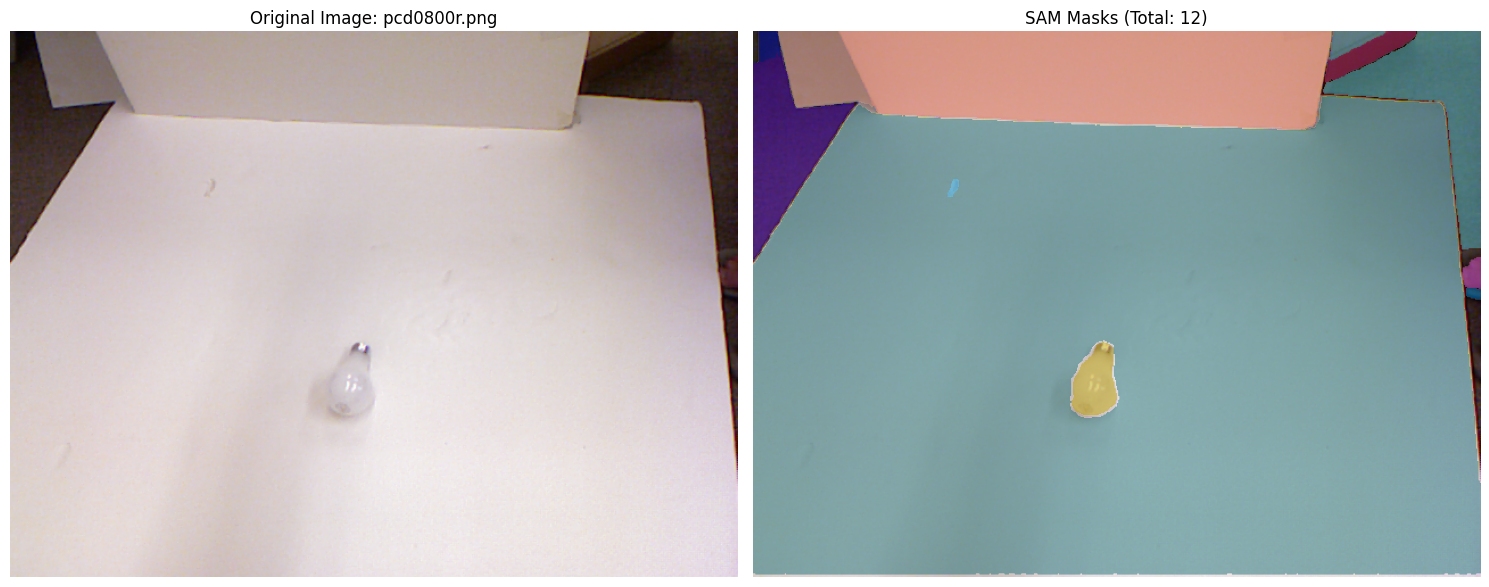


Generating masks for: pcd0801r.png
-> Total masks found: 14


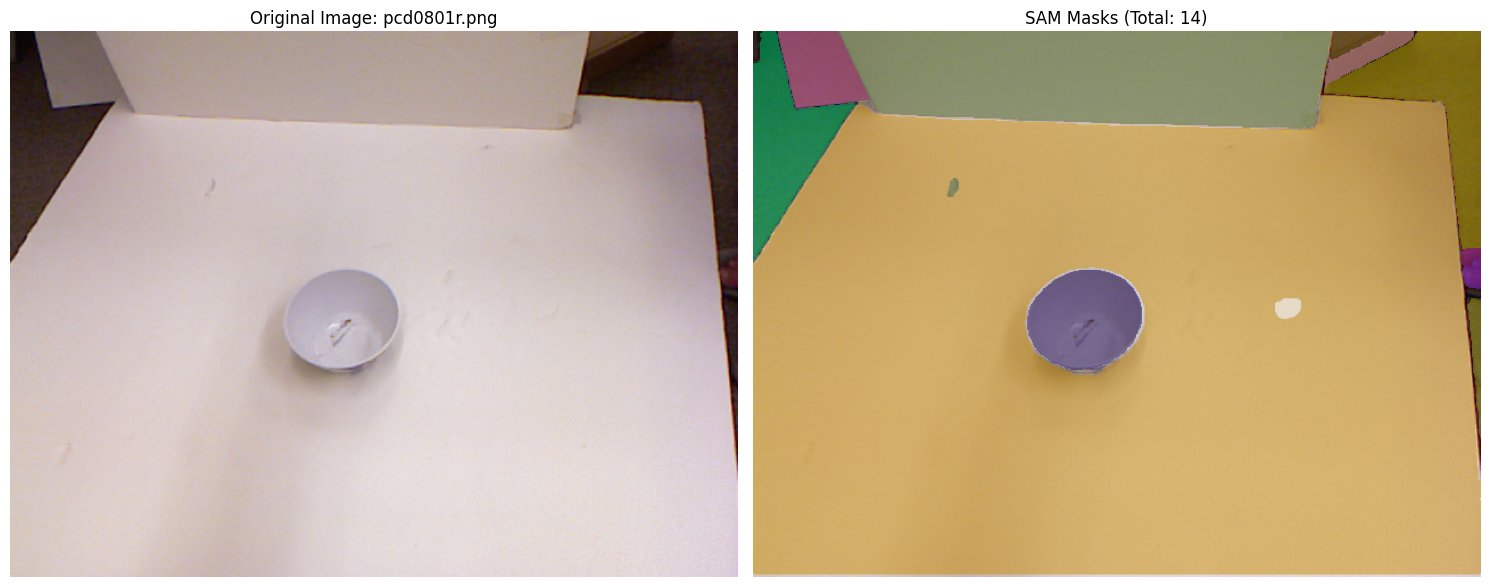


Generating masks for: pcd0802r.png
-> Total masks found: 17


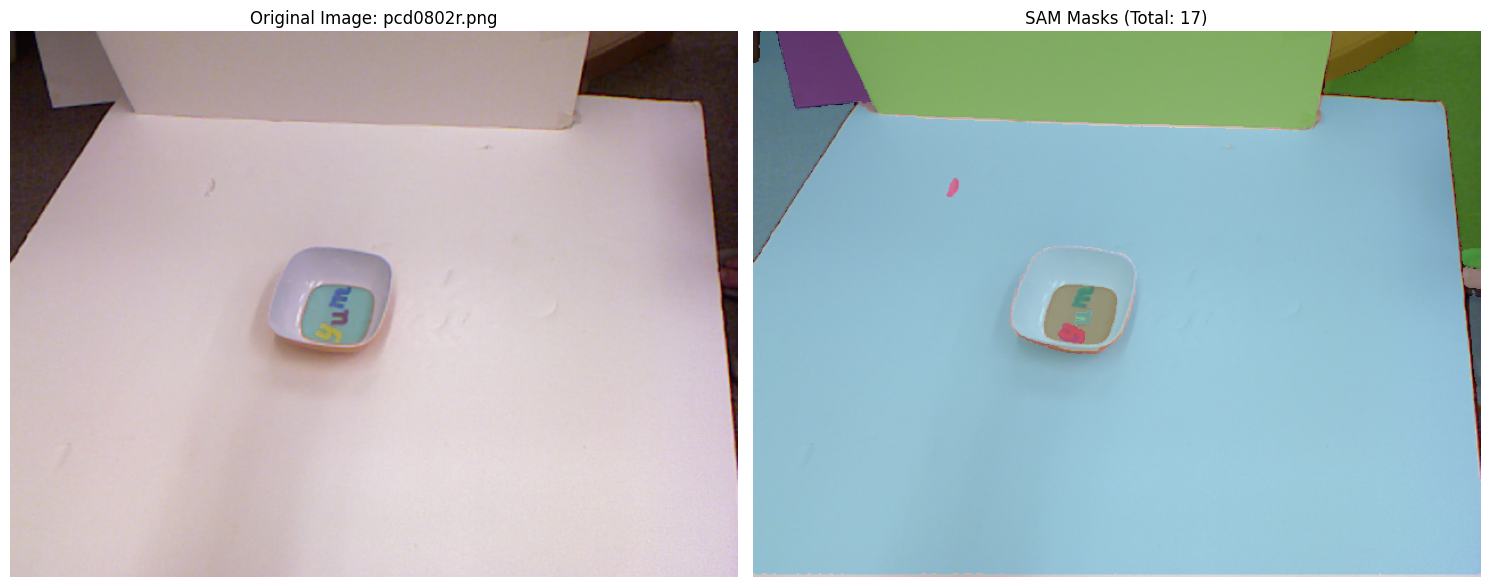


Generating masks for: pcd0803r.png
-> Total masks found: 16


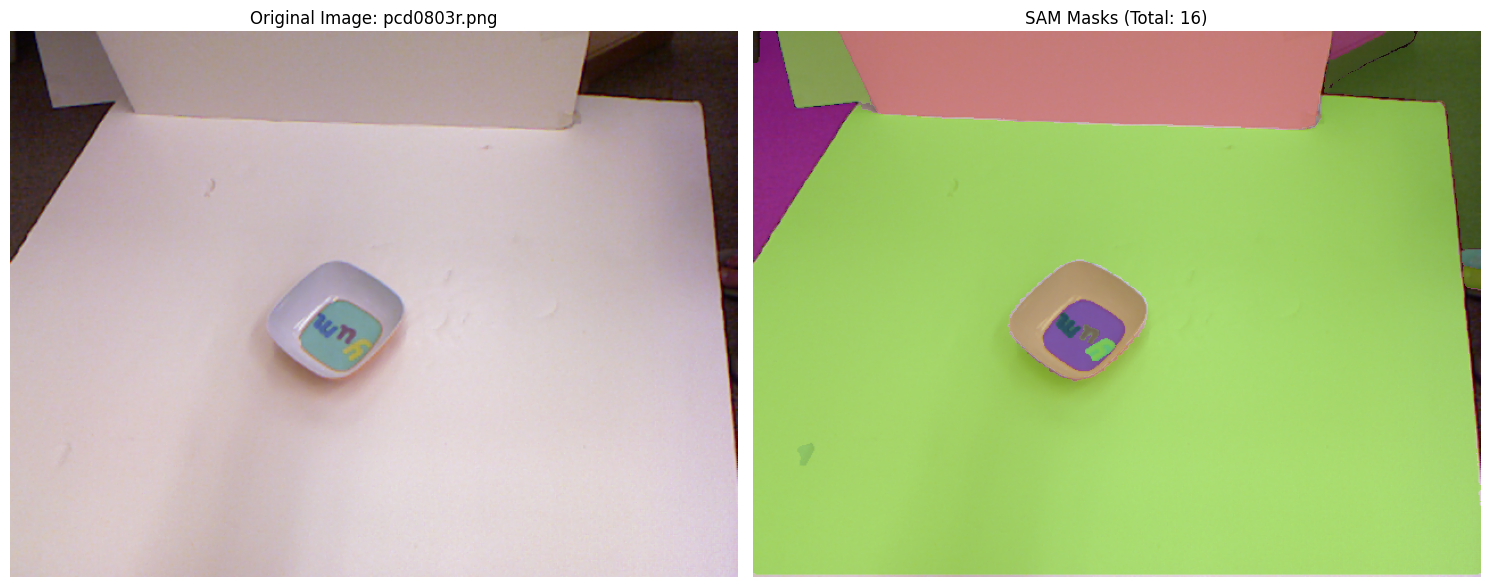


Generating masks for: pcd0804r.png
-> Total masks found: 9


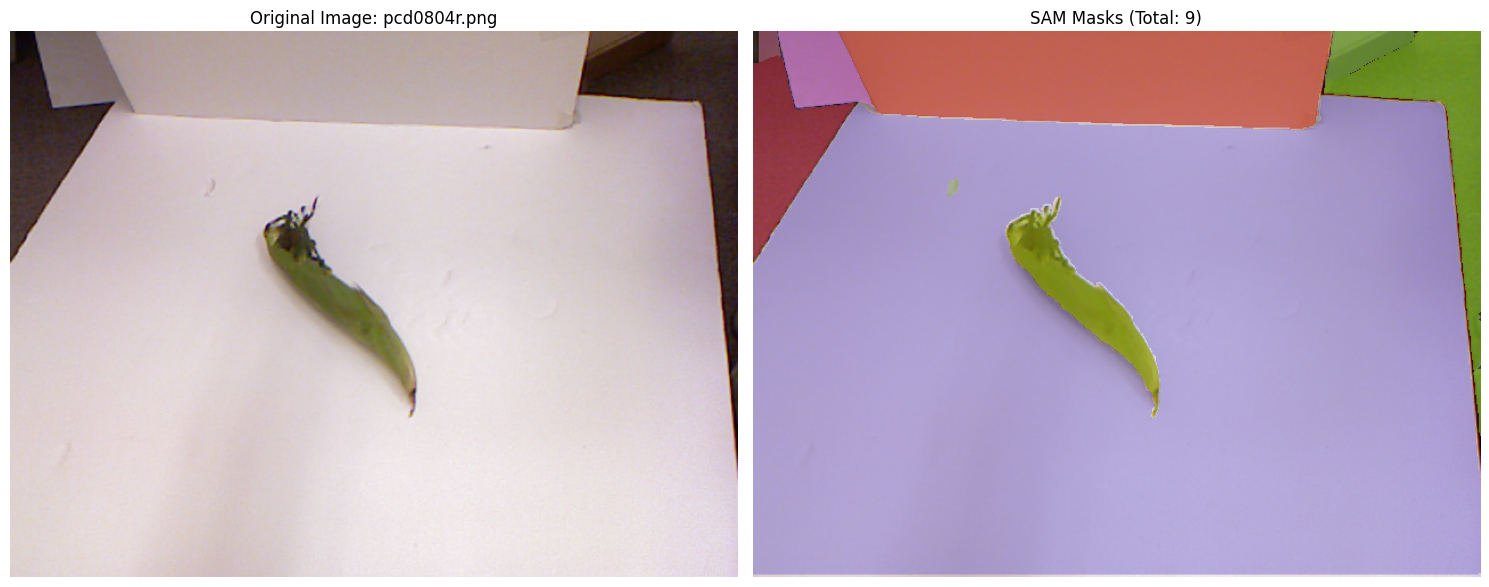


Generating masks for: pcd0805r.png
-> Total masks found: 8


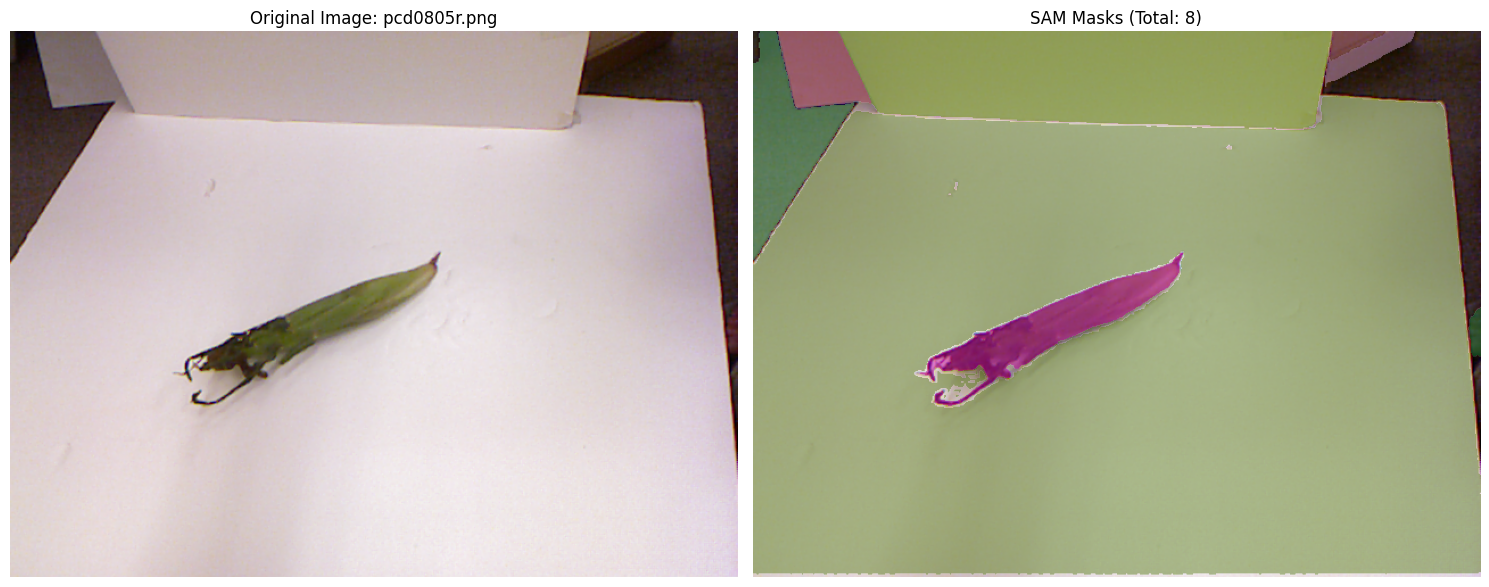

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import os


# C:\Users\park2\Desktop\archive

CHECKPOINT_PATH = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\sam_vit_b_01ec64.pth"
IMAGE_FOLDER = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\5_test_images"
MODEL_TYPE = "vit_b"

# --- 1. Load the SAM Model ---
print("Loading SAM model... this might take a few seconds.")
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=device)

# Initialize the automatic generator
mask_generator = SamAutomaticMaskGenerator(sam)

# --- Helper Function to Draw Masks ---
def show_anns(anns, ax):
    if len(anns) == 0:
        return
    # Sort masks by area so smaller masks are drawn on top of bigger ones
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax.set_autoscale_on(False)
    
    # Create a blank transparent image to draw colors on
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]]) 
        img[m] = color_mask
    ax.imshow(img)

# --- 2. Process the Images ---
image_files = [f for f in os.listdir(IMAGE_FOLDER)]

for img_file in image_files:
    img_path = os.path.join(IMAGE_FOLDER, img_file)
    
    #(CV2 loads as BGR, so we convert to RGB)
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    print(f"\nGenerating masks for: {img_file}")
    
    masks = mask_generator.generate(image_rgb)
    
    print(f"-> Total masks found: {len(masks)}")
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    axes[0].imshow(image_rgb)
    axes[0].set_title(f"Original Image: {img_file}")
    axes[0].axis('off')
    
    axes[1].imshow(image_rgb)
    show_anns(masks, axes[1]) # Apply our random color overlay
    axes[1].set_title(f"SAM Masks (Total: {len(masks)})")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


Image: pcd0800r.png | Total Masks Found: 12


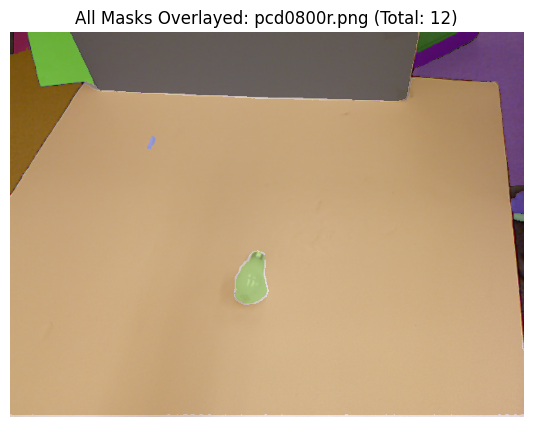

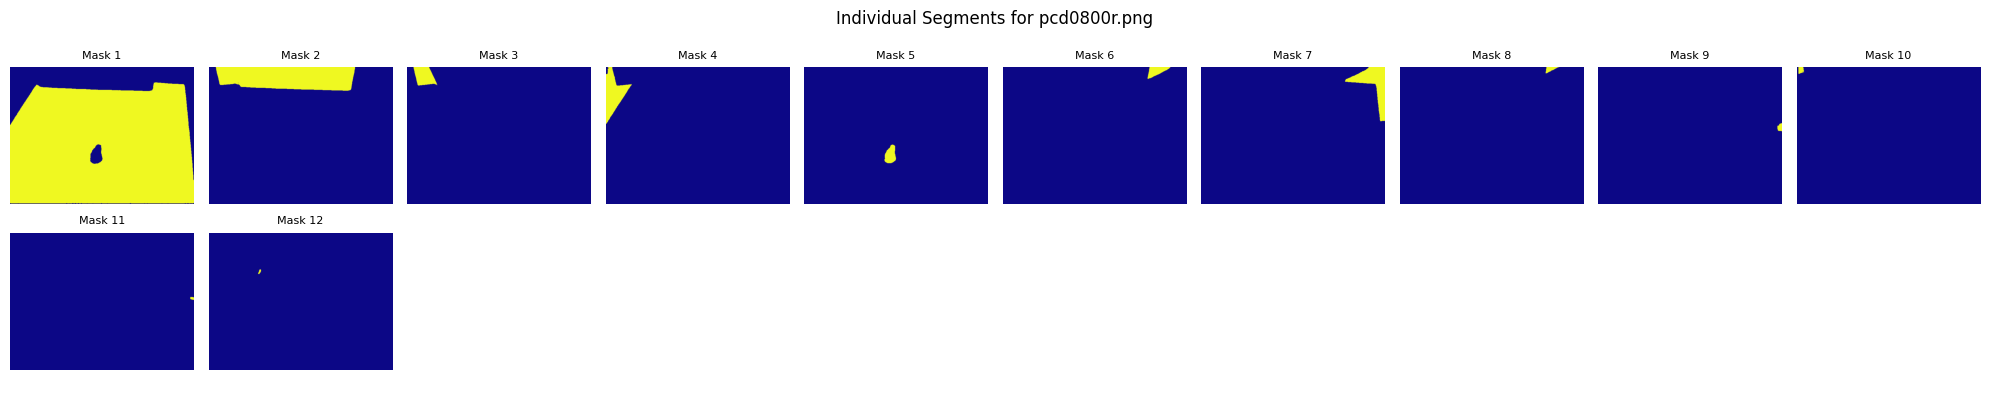


Image: pcd0801r.png | Total Masks Found: 14


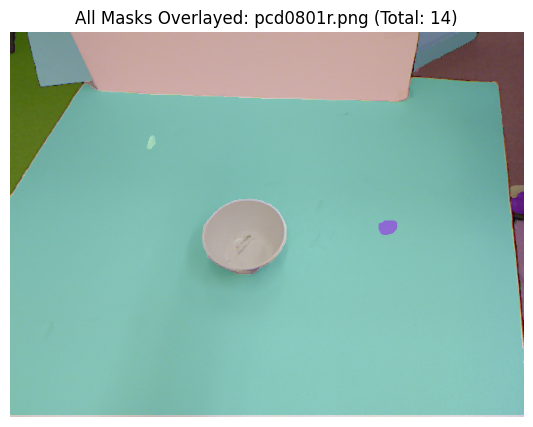

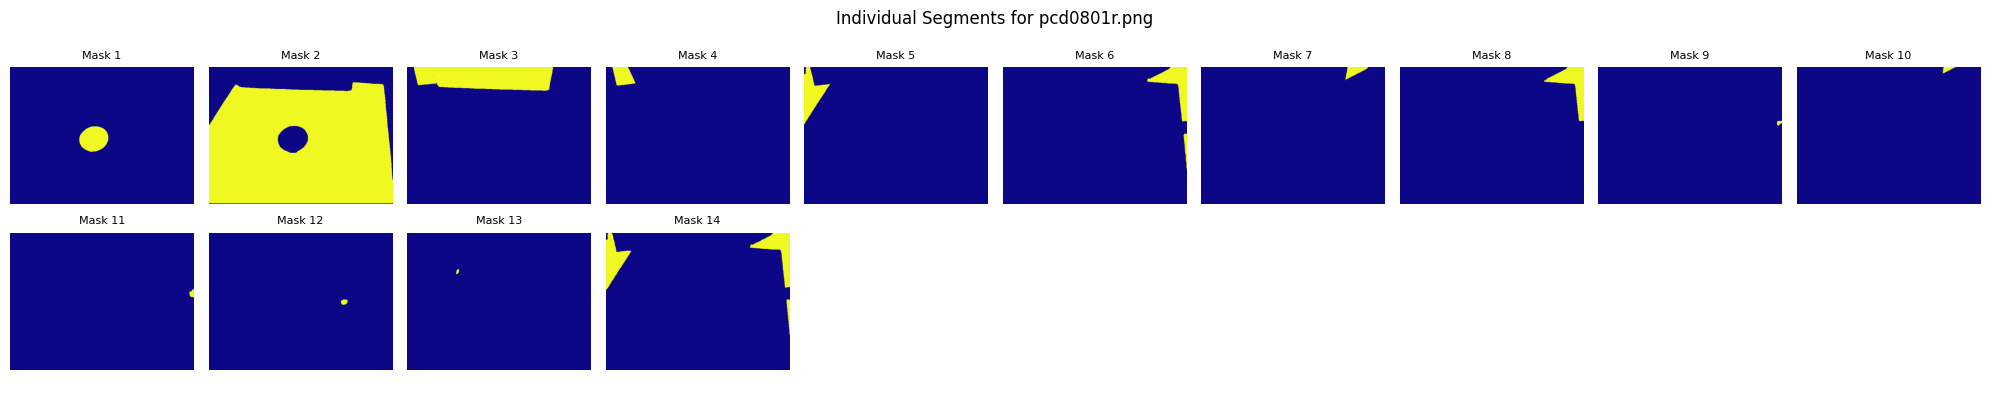


Image: pcd0802r.png | Total Masks Found: 17


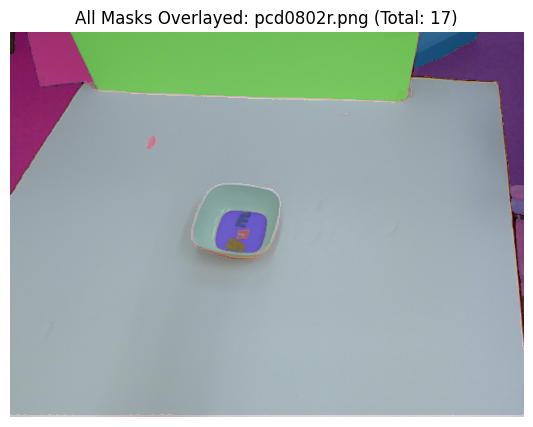

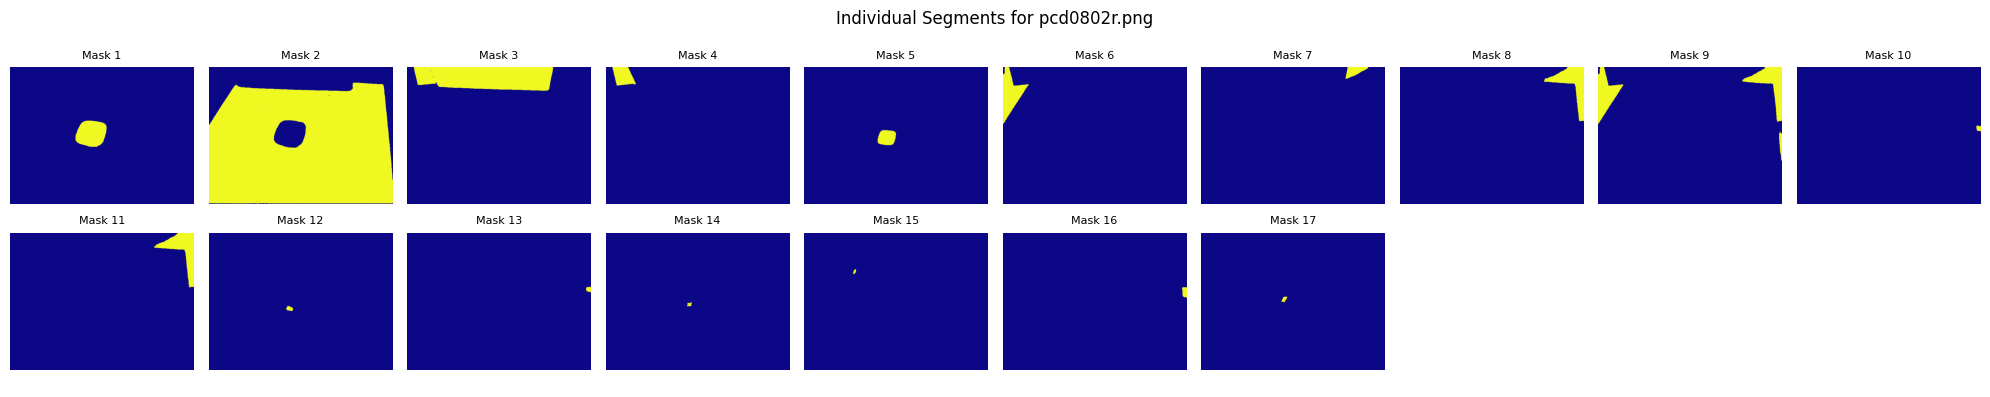


Image: pcd0803r.png | Total Masks Found: 16


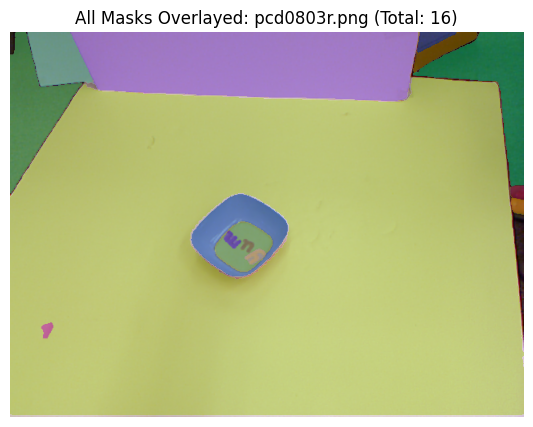

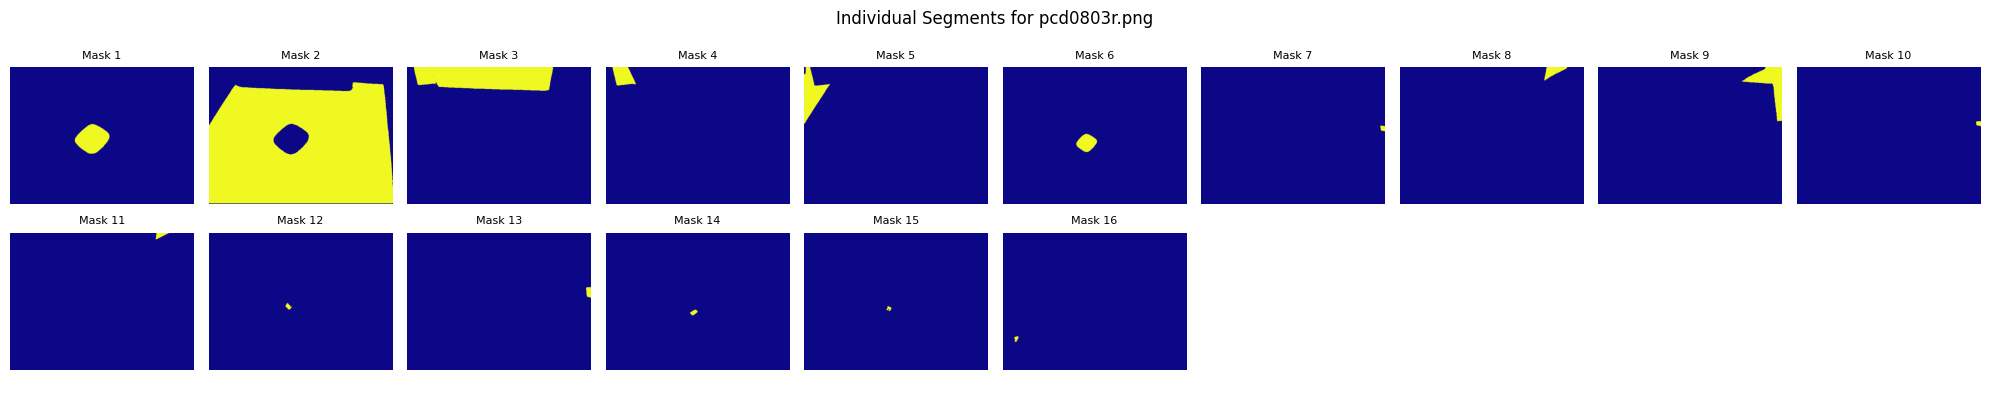


Image: pcd0804r.png | Total Masks Found: 9


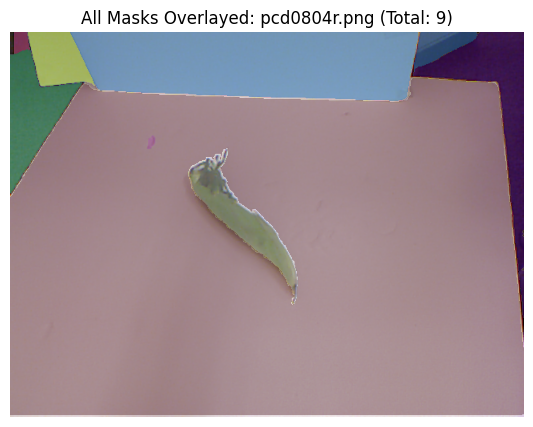

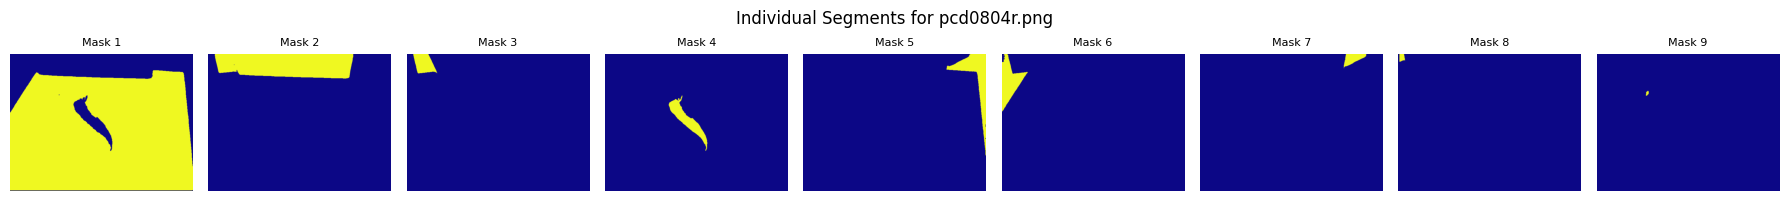


Image: pcd0805r.png | Total Masks Found: 8


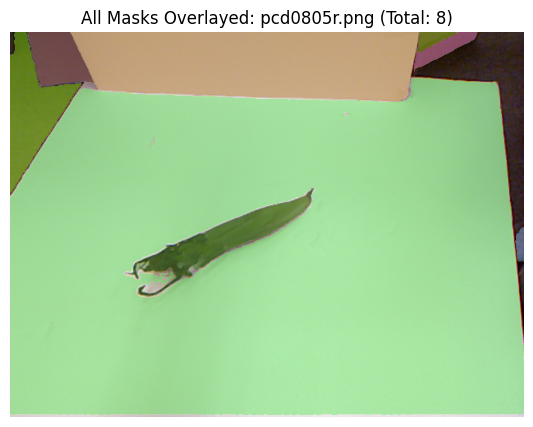

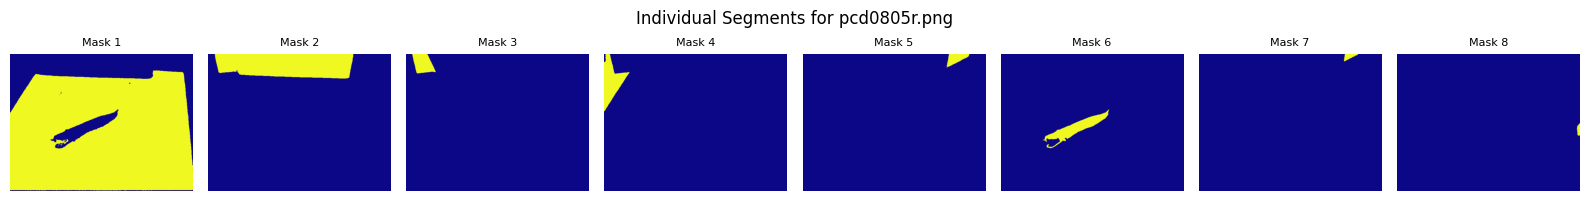

In [7]:
for img_file in image_files:
    img_path = os.path.join(IMAGE_FOLDER, img_file)
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    masks = mask_generator.generate(image_rgb)
    num_masks = len(masks)
    print(f"\nImage: {img_file} | Total Masks Found: {num_masks}")

    # 2. Show the Main Overlay (Step 3)
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.imshow(image_rgb)
    show_anns(masks, ax)
    ax.set_title(f"All Masks Overlayed: {img_file} (Total: {num_masks})")
    ax.axis('off')
    plt.show()

    # 3. Show Individual Masks (To see exactly what SAM "saw")
    cols = min(num_masks, 10)
    rows = (num_masks // cols) + (1 if num_masks % cols > 0 else 0)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).flatten()

    for i in range(len(axes)):
        if i < num_masks:
            axes[i].imshow(masks[i]['segmentation'], cmap='plasma')
            axes[i].set_title(f"Mask {i+1}", fontsize=8)
        axes[i].axis('off')
        
    plt.suptitle(f"Individual Segments for {img_file}")
    plt.tight_layout()
    plt.show()

# Analysis of SAM Foundation Model Results
The Segment Anything Model (SAM) did a surprisingly good job at zero-shot segmentation, especially considering it wasn't specifically trained on this robotic dataset. It managed to detect the contours of the objects really well, picking up on edges that even some supervised models might struggle with. However, a major takeaway from the results is the lack of object context. For example, in images pcd0802r and pcd0803r, SAM splits the bowl into two separate objects—treating the inner and outer shapes as independent items. Because the model doesn't "know" it's looking at a bowl, it just sees two distinct geometric boundaries and segments them accordingly.

Another interesting downside is seen in images like pcd0804 and pcd0805 (specifically Mask 8). SAM often generates masks that don't really represent a single "factual" object, but are instead based on specific angles, lighting, or specs on the table. While this leads to over-segmentation for a robot trying to pick up a bowl, it actually hints at a huge strength in other fields. This level of sensitivity—detecting things only a few pixels wide—would be incredibly useful for finding tiny dust specks on a semiconductor wafer or identifying small protein dots in a biological sample. In those cases, SAM's tendency to over-segment becomes a high-precision tool for quality control.